# Analyze global fit results

In [30]:
import numpy as np
import sys
import os
import subprocess
import matplotlib as mpl
from matplotlib import pyplot as plt
from copy import deepcopy

mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["savefig.dpi"] = 600


sys.path.append(os.path.abspath("/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/"))

# Enable autoreload extension
%load_ext autoreload

# Reload only the utils package before running a cell
%autoreload 1
%aimport fit_utils
%aimport fit_utils.utils
%aimport fit_utils.pullplots
%aimport fit_utils.parser
%aimport fit_utils.EFT_matching

import fit_utils.utils as utils
import fit_utils.pullplots as pullplots
import fit_utils.parser as parser
import fit_utils.EFT_matching as EFT_matching

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



Finding configuration files for the observables

Setting configuration files for scenario: . model spec: fits_small_priors_long
Files considered:
- Globalfits/AllOps/d6Ops_corr.conf

Reading configuration files for observables
Reading configuration file ./SM_fit/./Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



{'SM_fit': {'.': {'fits_small_priors_long': ['CW_corr', 'CHG_corr', 'CHW_corr', 'CHB_corr', 'CHWB_corr', 'CHD_corr', 'CHbox_corr', 'CHL1_11_corr', 'CHL1_22_corr', 'CHL1_33_corr', 'CHL3_11_corr', 'CHL3_22_corr', 'CHL3_33_corr', 'CHe_11_corr', 'CHe_22_corr', 'CHe_33_corr', 'CHQ1_11_corr', 'CHQ1_33_corr', 'CHQ3_11_corr', 'CHu_11_corr', 'CHd_11_corr', 'CHd_33_corr', 'CeH_22r_corr', 'CeH_33r_corr', 'CuH_22r_corr', 'CuH_33r_corr', 'CdH_33r_corr', 'CLL_1221_corr', 'CH_corr']}}}

Reading fit results
Reading file: ./SM_fit/./results_fits_small_priors_long/Observables/Statistics.txt

Parameter dictionary: 
{'SM_fit': {'.': {'fits_small_priors_long': ['CW_corr', 'CHG_corr', 'CHW

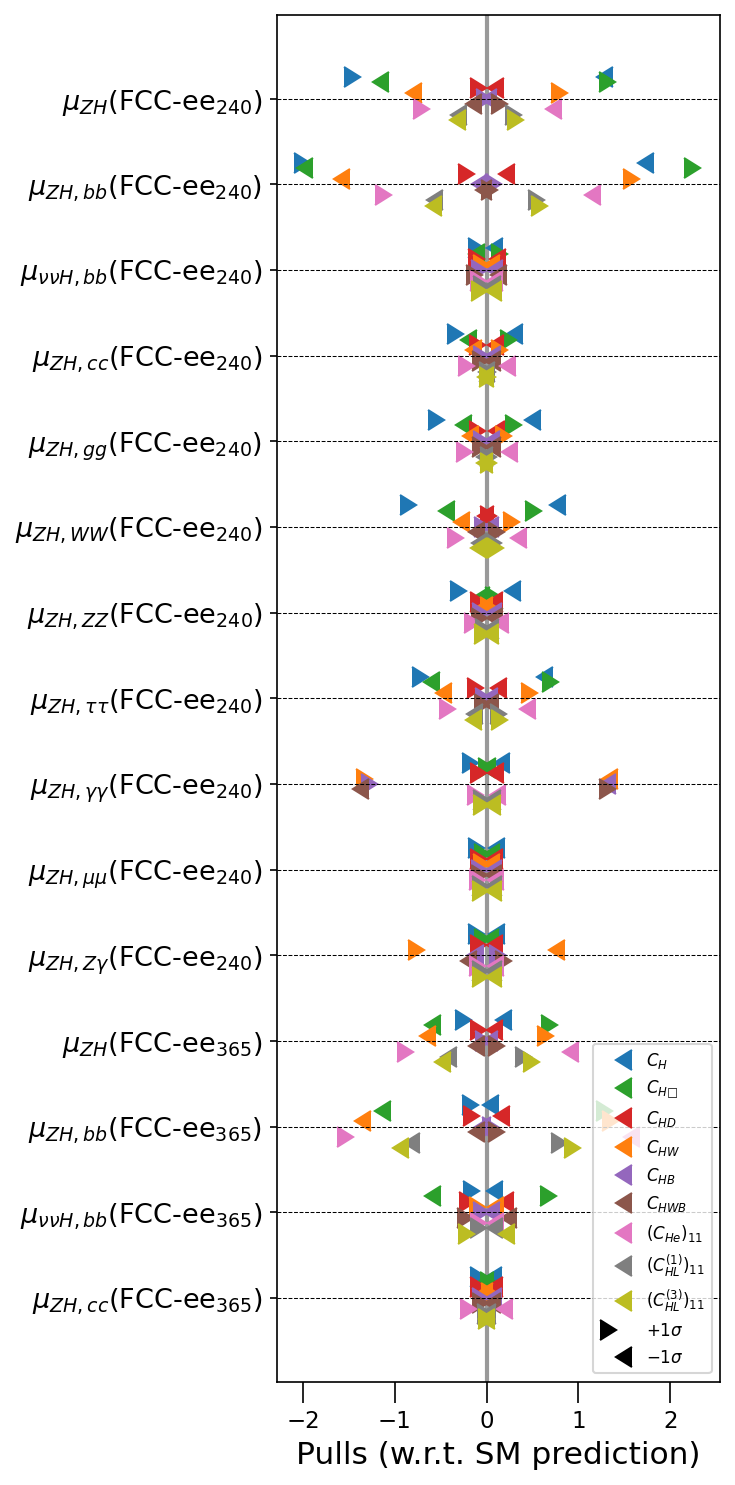

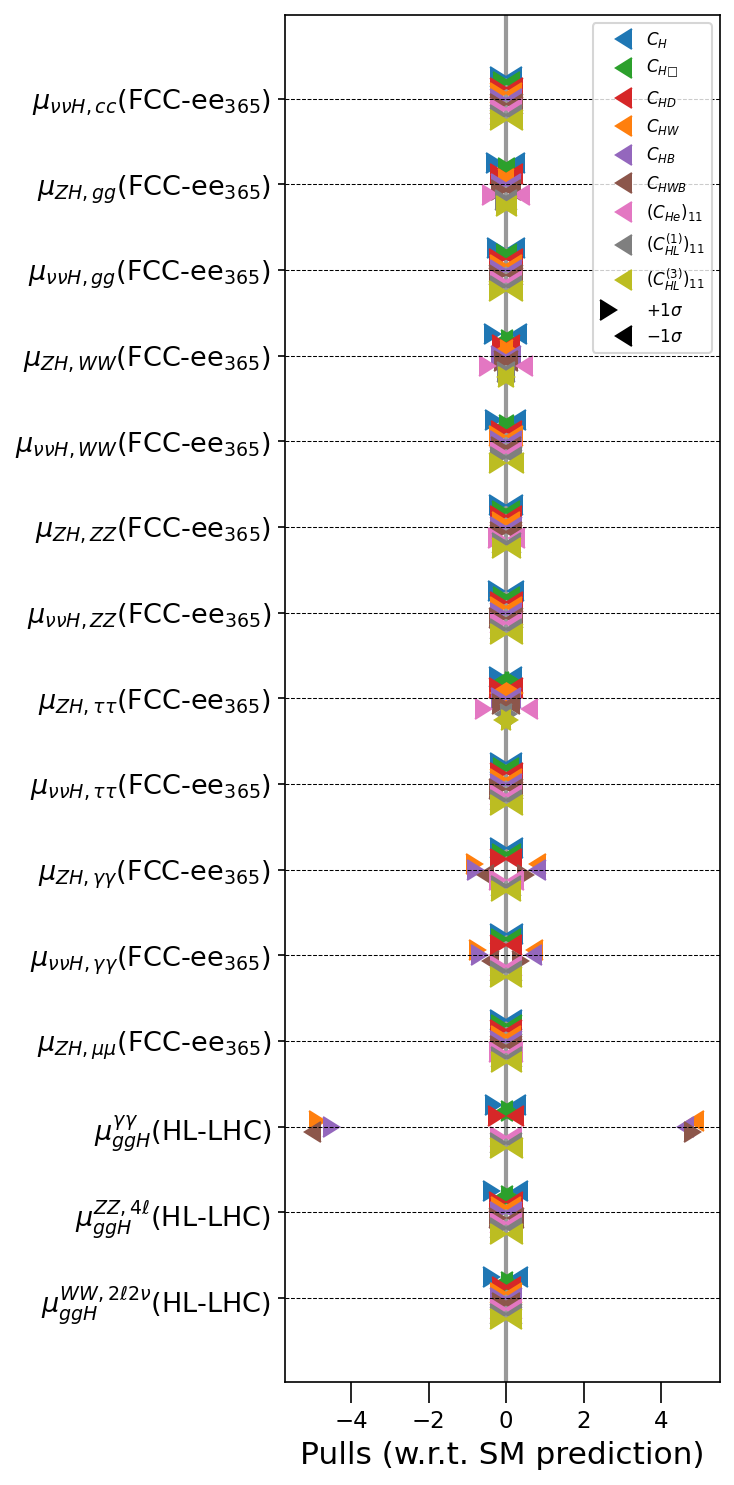

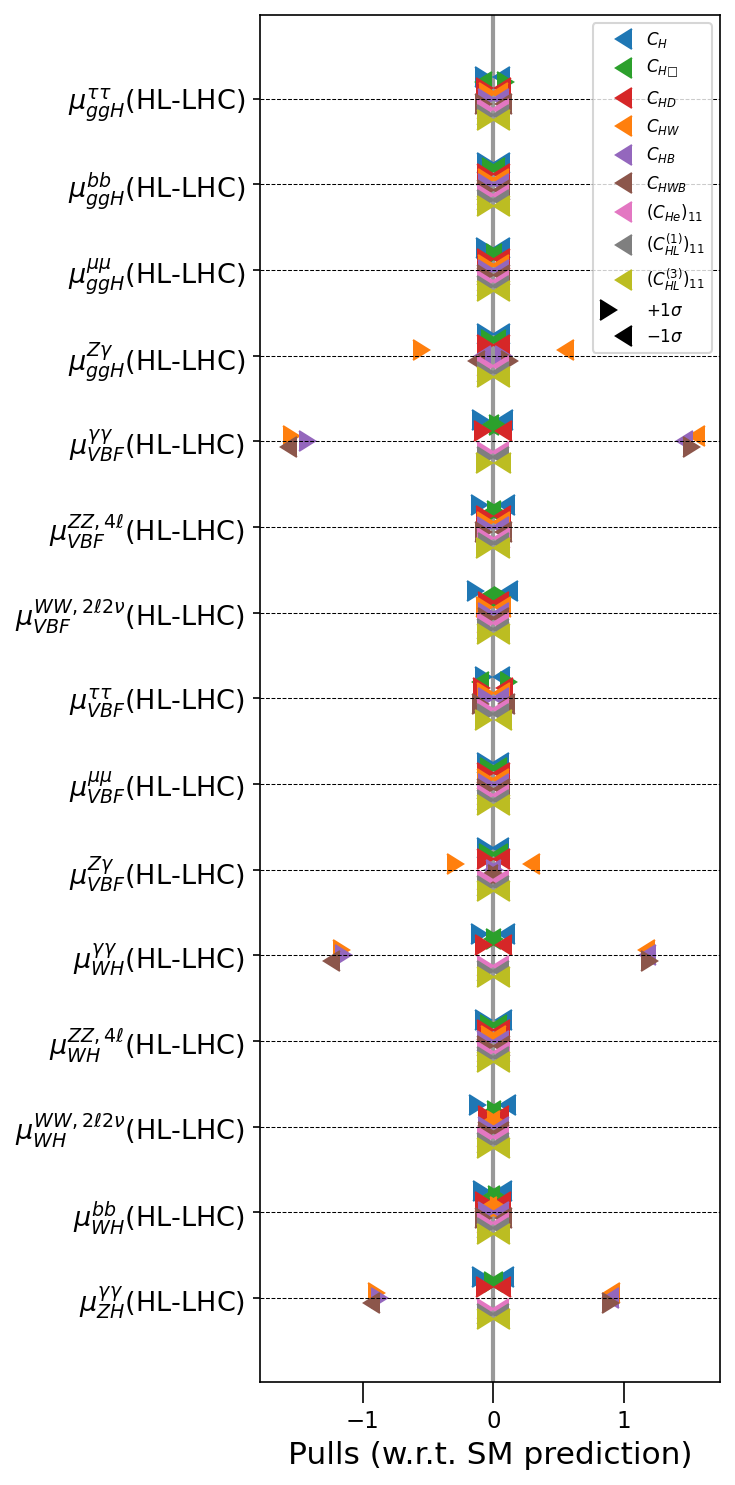

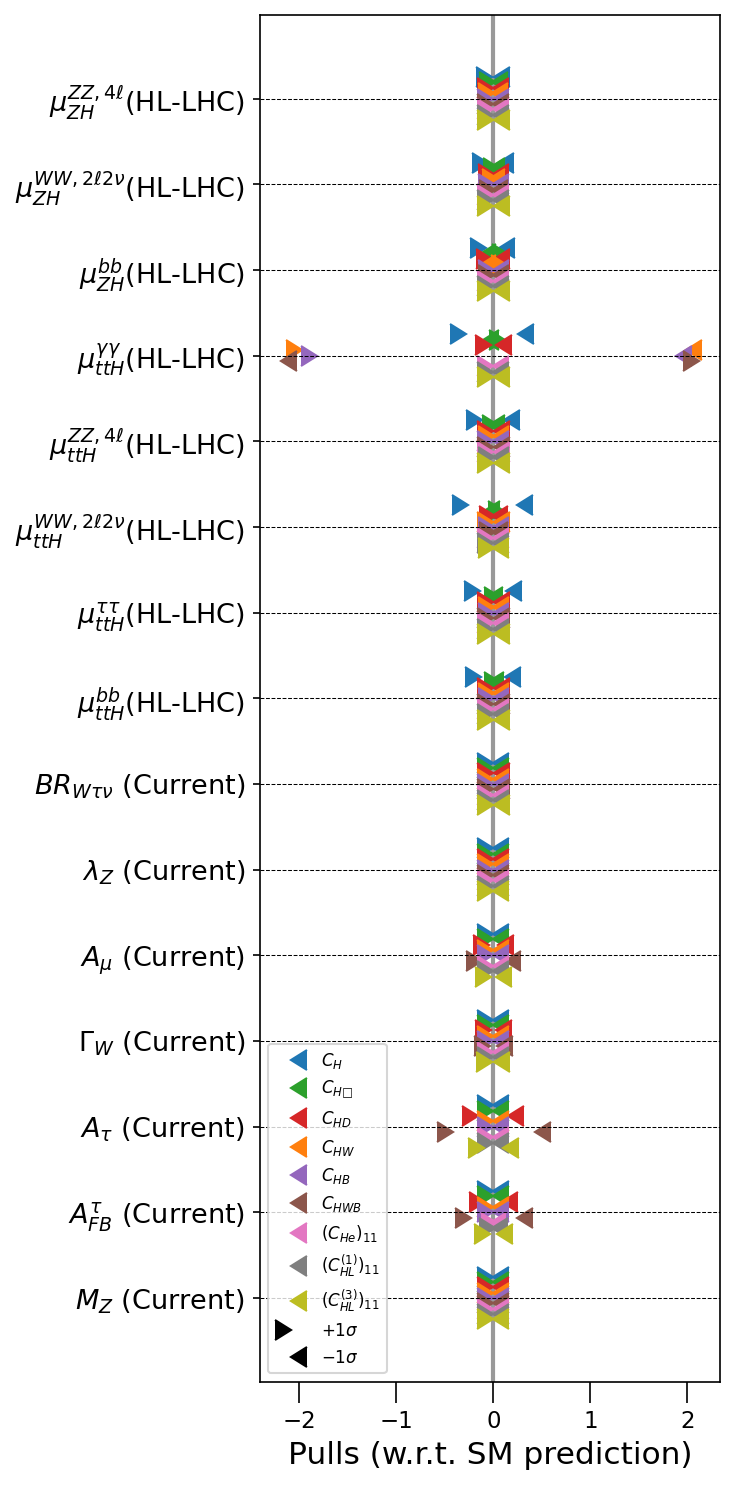

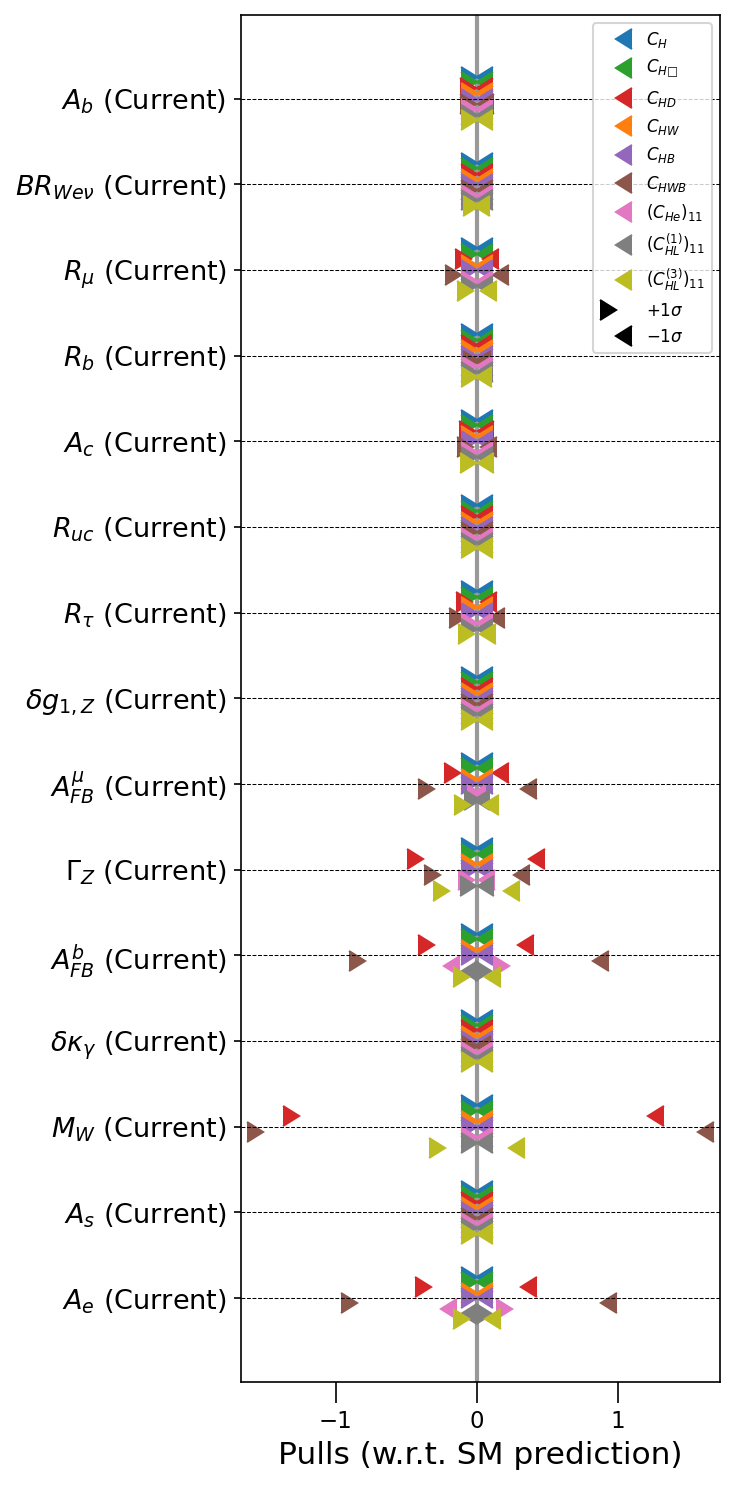

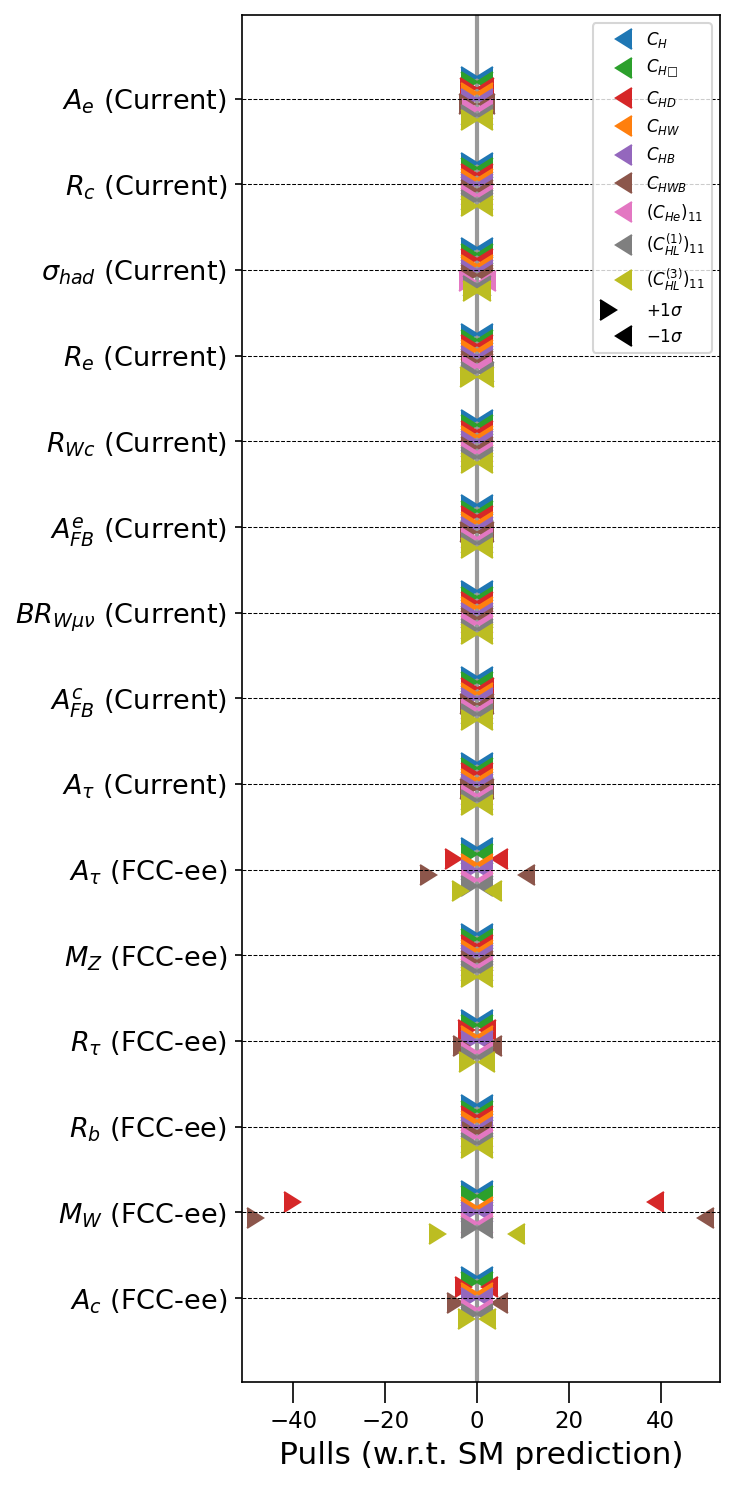

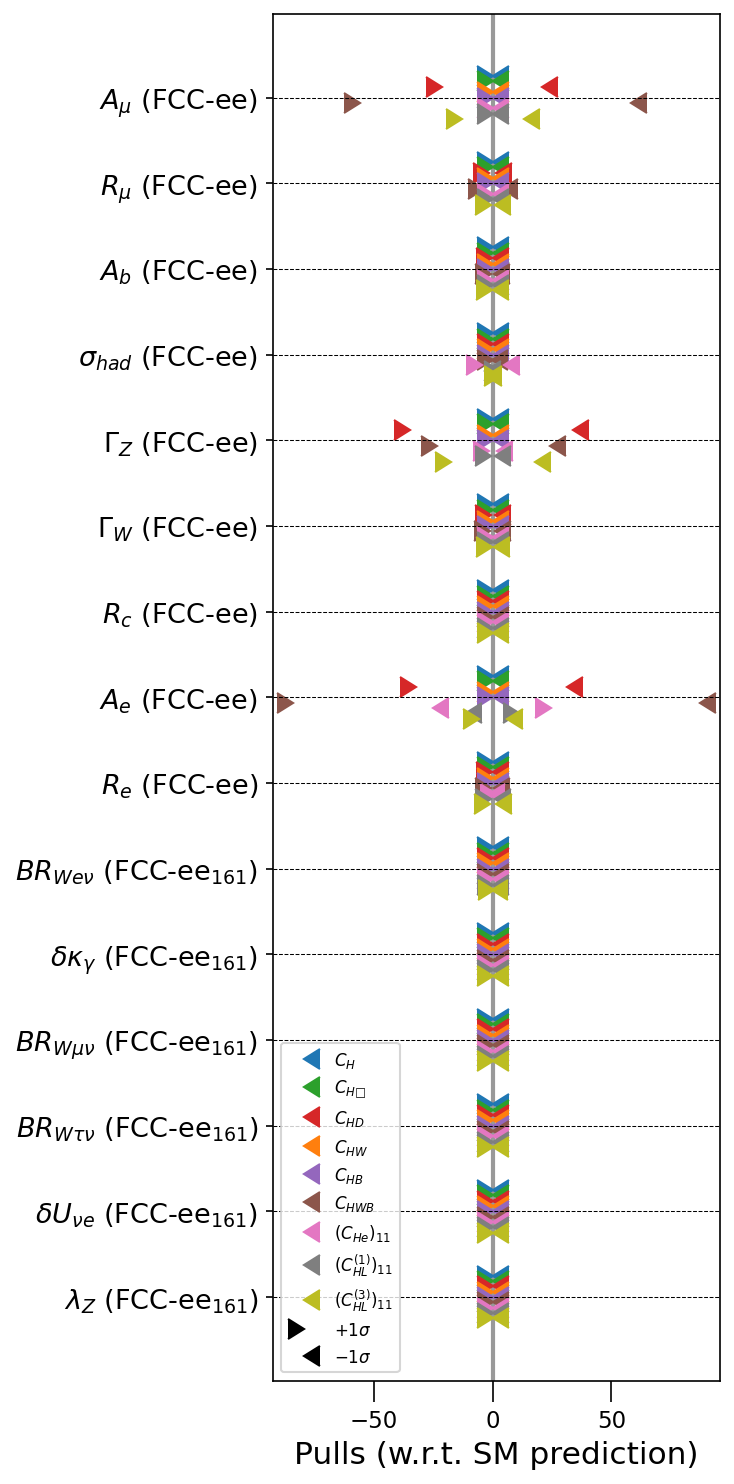

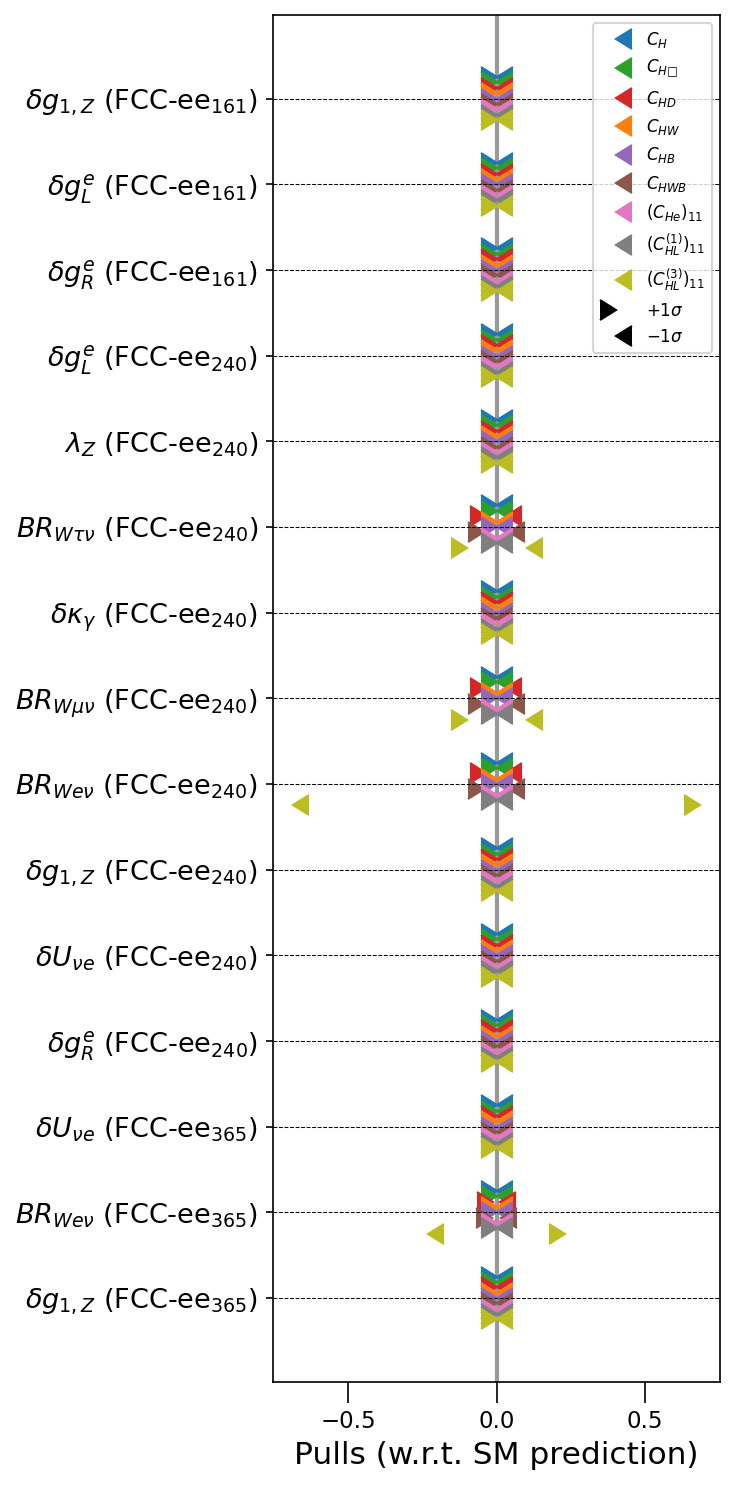

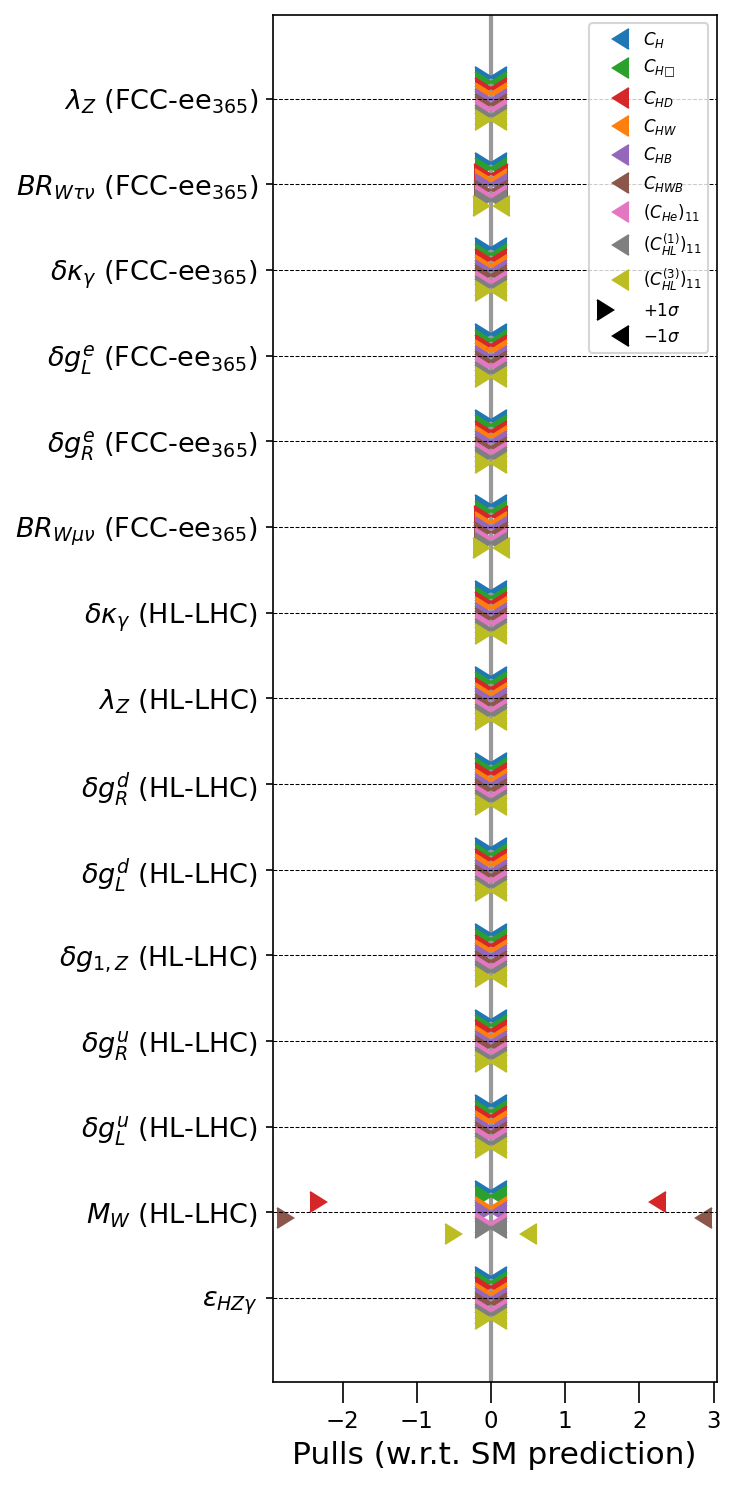

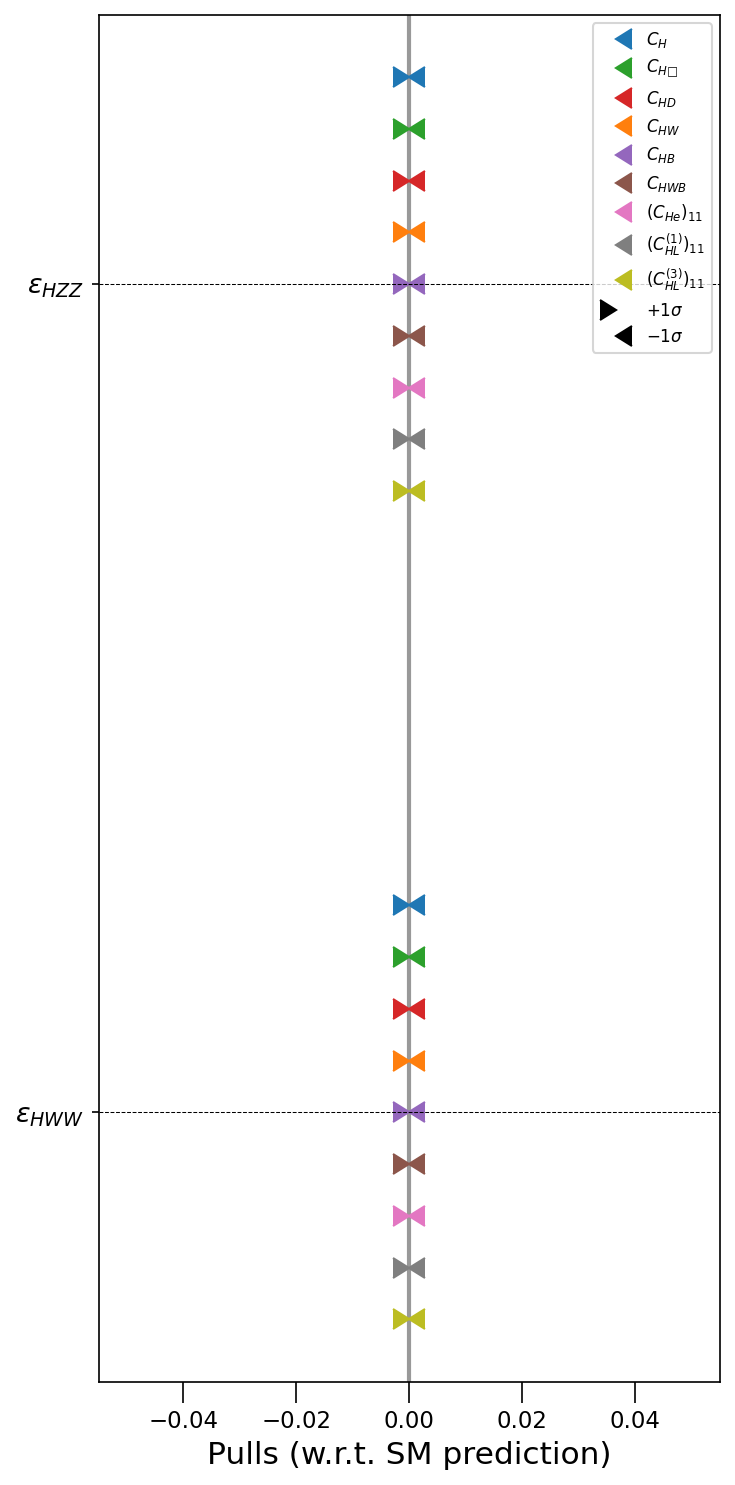

In [35]:
from fit_utils.parser import read_configuration_files, observable_order, align_observables, find_tex_label_par
from find_1sigma_WCs import find_1sigma_WCs

# WCs = ["CH", "CHbox", "CHD", "CHW", "CHG", "CHB", "CHWB", "CuH_33r"]
# WCs = ["CH", "CHbox", "CHD", "CHW", "CHG", "CHB", "CHWB",]
WCs = ["CH", "CHbox", "CHD", "CHW", "CHB", "CHWB", "CHe_11", "CHL1_11", "CHL3_11"]
# WCs = ["CH", "CuH_33r"]

# WC_labels = [ find_tex_label_par(None, wc) + r"$=1$" for wc in WCs ]
WC_labels = [ find_tex_label_par(None, wc) for wc in WCs ]

# WC_values = np.linspace(0.01, 0.01, 1)
WC_values = find_1sigma_WCs(WCs)
WC_values = np.array([[WC_values[wc+ "_low"], WC_values[wc+ "_high"]] for wc in WCs])
n_WC_values = WC_values.shape[1]


working_dir = "."
results_dir = "fits_small_priors_strict"
BPs = ["Config_Files", ]
# model_specs = {"." : [".", ]}
specs = ['fits_small_priors_strict', ]
model_specs = {"." : specs}
scenarios = model_specs.keys()
file_suffix = "_all"
x_range_min = None
x_range_max = None

nvar_per_plot=15
figsize=(5, 10)
legend_loc="best"
log_scale=False
colors = ["tab:blue", "tab:green", "tab:red", "tab:orange", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]
# plot_titles = [""]
plot_dir = f"{working_dir}/plots/"

plot_titles = { 
    BP : {
        scenario : ""
        for scenario in scenarios
    } 
    for BP in BPs
}

# subprocess.run(["mkdir", "-p", f"{plot_dir}"])

# conf_file_list = [
#     "ObservablesEW.conf",
#     "ObservablesEW_Current_SM_noLFU.conf",
#     "ObservablesEW_FCCee_Zpole_SM.conf",
#     "ObservablesEW_FCCee_WW_SM.conf",
#     "ObservablesEW_HLLHC.conf",
#     "ObservablesHiggs.conf",
#     "ObservablesHiggs_FCCee_240_SM.conf",
#     "ObservablesHiggs_FCCee_365.conf",
#     "ObservablesHiggs_HLLHC_SM.conf",
#     "ObservablesVV.conf",
#     "aTGC_observables_Current.conf",
#     "aTGC_observables_HLLHC_Full.conf",
#     "ObservablesVV_OO_FCCee_161.conf",
#     "ObservablesVV_OO_FCCee_240.conf",
#     "ObservablesVV_OO_FCCee_365.conf",
#     "EffVHcouplings_QFU12.conf",
#     "HiggsEW_Par_Corr.conf",
# ]
# conf_files = { scenario : {spec : conf_file_list for spec in model_specs[scenario]} for scenario in scenarios}

# observables, observables_tex, central_values_obs, input_uncertainties = read_configuration_files(
#     working_dir,
#     BPs,
#     model_specs,
#     conf_files,
# )
# print("central_values_obs: " , central_values_obs["Config_Files"]["."]['fits_small_priors_strict'])
# print("Input uncertainties: " , input_uncertainties["Config_Files"]["."]['fits_small_priors_strict'])

# results = {}
# for BP in BPs:
#     results[BP] = {}
#     for scenario in scenarios:
#         results[BP][scenario] = {}
#         for model_spec in model_specs[scenario]:
#             results[BP][scenario][model_spec] = np.zeros((len(observables["Config_Files"]["."]['fits_small_priors_strict']), 2))
#             results[BP][scenario][model_spec] = np.array( 
#                 [
#                     central_values_obs["Config_Files"]["."]['fits_small_priors_strict'],
#                     input_uncertainties["Config_Files"]["."]['fits_small_priors_strict'],
#                 ] 
#             ).T

# aligned_observables, aligned_observables_tex, central_values_obs, results = align_observables(
#         observable_order_func=observable_order,
#         BPs=BPs,
#         model_specs=model_specs,
#         observables=observables,
#         observables_tex=observables_tex,
#         central_values_obs=central_values_obs,
#         results=results,
#     )
# print(central_values_obs["Config_Files"]["."])
# print(aligned_observables["Config_Files"]["."])


# obs_predictions = parser.read_WC_predictions(
#     working_dir,
#     WCs,
#     n_WC_values,
#     aligned_observables,
# )

# # print(obs_predictions)


# n_WCs = len(WCs)
# w = 1.0
# dimw = w / 2
# bar_height = dimw / n_WCs
# if n_WCs > 1:
#     y_shift = np.linspace(+dimw/2, -dimw/2, n_WCs) 
# else:
#     y_shift = np.array([0])

# print(f"\n")
# num_fig = 0


# param_breaks = np.arange(0, len(aligned_observables["Config_Files"]["."]), nvar_per_plot)

# if len(param_breaks)==1 or param_breaks[-1] != len(aligned_observables["Config_Files"]["."]):
#     param_breaks = np.append(param_breaks, [len(aligned_observables["Config_Files"]["."])])

# print(f"\nProducing plots for {BP}, scenario {scenario}")
# print(f"Total number of parameters: {len(aligned_observables['Config_Files']['.'])}")
# print(f"Parameter breaks: {param_breaks}")

# labels = aligned_observables_tex["Config_Files"]["."][:]
# for j, par in enumerate(aligned_observables_tex["Config_Files"]["."]):
#     labels[j] = par

# for k in range(len(param_breaks) - 1):

#     fig = plt.figure(num_fig, figsize=figsize)
#     num_fig = num_fig + 1
#     ax = plt.gca()

#     y = np.arange(param_breaks[k],param_breaks[k+1])
    
#     plt.axvline(x=0, c='0.6', linewidth=2)

#     print("Central values:", central_values_obs["Config_Files"]["."]['fits_small_priors_strict'])
#     print("Central values (results array):", results["Config_Files"]["."]['fits_small_priors_strict'][:,0] )
#     print("Input uncertainties: ", results["Config_Files"]["."]['fits_small_priors_strict'][:,1] )
    
#     for i, wc in enumerate(WCs):
#         plotted_results_low = deepcopy( (obs_predictions[wc][0] - central_values_obs["Config_Files"]["."]['fits_small_priors_strict'])/results["Config_Files"]["."]['fits_small_priors_strict'][:,1] )
#         plotted_results_high = deepcopy( (obs_predictions[wc][1] - central_values_obs["Config_Files"]["."]['fits_small_priors_strict'])/results["Config_Files"]["."]['fits_small_priors_strict'][:,1] )
#         ax.plot(
#             plotted_results_low[param_breaks[k]:param_breaks[k+1]],
#             -y+y_shift[i], 
#             # -y, 
#             linestyle="None",
#             marker=4, 
#             markersize=10,
#             # xerr = (results[BP][scenario][model_spec][param_breaks[k]:param_breaks[k+1], 1],), 
#             color=colors[i],
#             label=WC_labels[i],
#             # alpha=alphas[i],
#         )

#         ax.plot(
#             plotted_results_high[param_breaks[k]:param_breaks[k+1]],
#             -y+y_shift[i], 
#             # -y, 
#             linestyle="None",
#             marker=5, 
#             markersize=10,
#             color=colors[i],
#         )

#     ax.plot([], [], marker=5, markersize=10, linestyle="None", color="black", label="$+1\sigma$")
#     ax.plot([], [], marker=4, markersize=10, linestyle="None", color="black", label="$-1\sigma$")

#     ax.set_xscale('log' if log_scale else 'linear')
        
#     # ax.set_yticks(-y-dimw/2.)
#     ax.set_yticks(-y)
#     y_label_size = min( 400. / (param_breaks[k+1] - param_breaks[k]), 13)
#     ax.set_yticklabels(labels[param_breaks[k]:param_breaks[k+1]], fontsize=y_label_size)
#     x_limits = [
#         x_range_min if not x_range_min is None else plt.xlim()[0], 
#         x_range_max if not x_range_max is None else plt.xlim()[1], 
#     ]
#     ax.hlines(y=-y, xmin=x_limits[0], xmax=x_limits[1], color="black", linestyle="--", linewidth=0.5)
#     ax.set_xlim(*x_limits)
#     ax.tick_params(axis='x', size=10, labelsize=11)
#     ax.tick_params(axis='x', which='minor', size=6)
#     x_label = r'Pulls (w.r.t. SM)'
#     ax.set_xlabel(x_label, fontsize=10)
#     ax.legend(loc=legend_loc, fontsize=10)
#     ax.set_title(plot_titles[i], fontsize=10)
#     plt.tight_layout()   # Makes sure labels are not cut off
#     plt.savefig(f"{results_dir}/pull_plot_obs_compare_{k}{file_suffix}.pdf")


pullplots.generate_pull_plots_obs(
    BPs,
    model_specs,
    working_dir,
    results_dir,
    model_specs_labels=None,
    plot_titles=plot_titles,
    model="SM",
    only_obs=None,
    skip_obs=None,
    colors=colors,
    show_plots=True,
    nvar_per_plot=nvar_per_plot,
    only_higgs_fccee_obs=False,
    compare_with_SM=False,
    WC_list_for_prediction_pulls=WCs,
    figsize=figsize,
    legend_loc=legend_loc,
    file_suffix=file_suffix,
    save_fig=True,
)


Finding configuration files for the observables

Reading configuration files for observables
Reading configuration file ./Config_Files/./ObservablesEW.conf
Reading configuration file ./Config_Files/./ObservablesEW_Current_SM_noLFU.conf
Reading configuration file ./Config_Files/./ObservablesEW_FCCee_Zpole_SM.conf
Reading configuration file ./Config_Files/./ObservablesEW_FCCee_WW_SM.conf
Reading configuration file ./Config_Files/./ObservablesEW_HLLHC.conf
Reading configuration file ./Config_Files/./ObservablesHiggs.conf
Reading configuration file ./Config_Files/./ObservablesHiggs_FCCee_240_SM.conf
Reading configuration file ./Config_Files/./ObservablesHiggs_FCCee_365.conf
Reading configuration file ./Config_Files/./ObservablesHiggs_HLLHC_SM.conf
Reading configuration file ./Config_Files/./ObservablesVV.conf
Reading configuration file ./Config_Files/./aTGC_observables_Current.conf
Reading configuration file ./Config_Files/./aTGC_observables_HLLHC_Full.conf
Reading configuration file ./Co

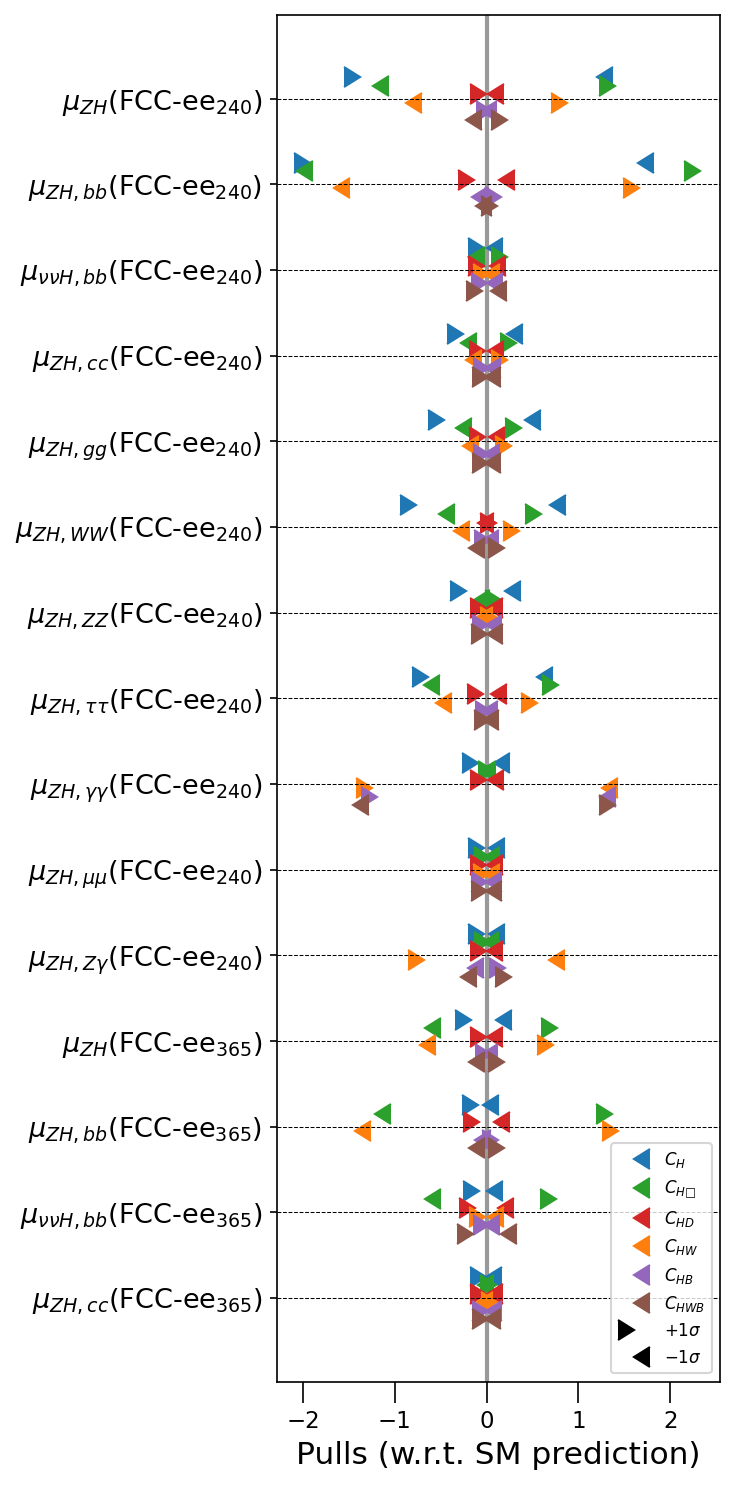

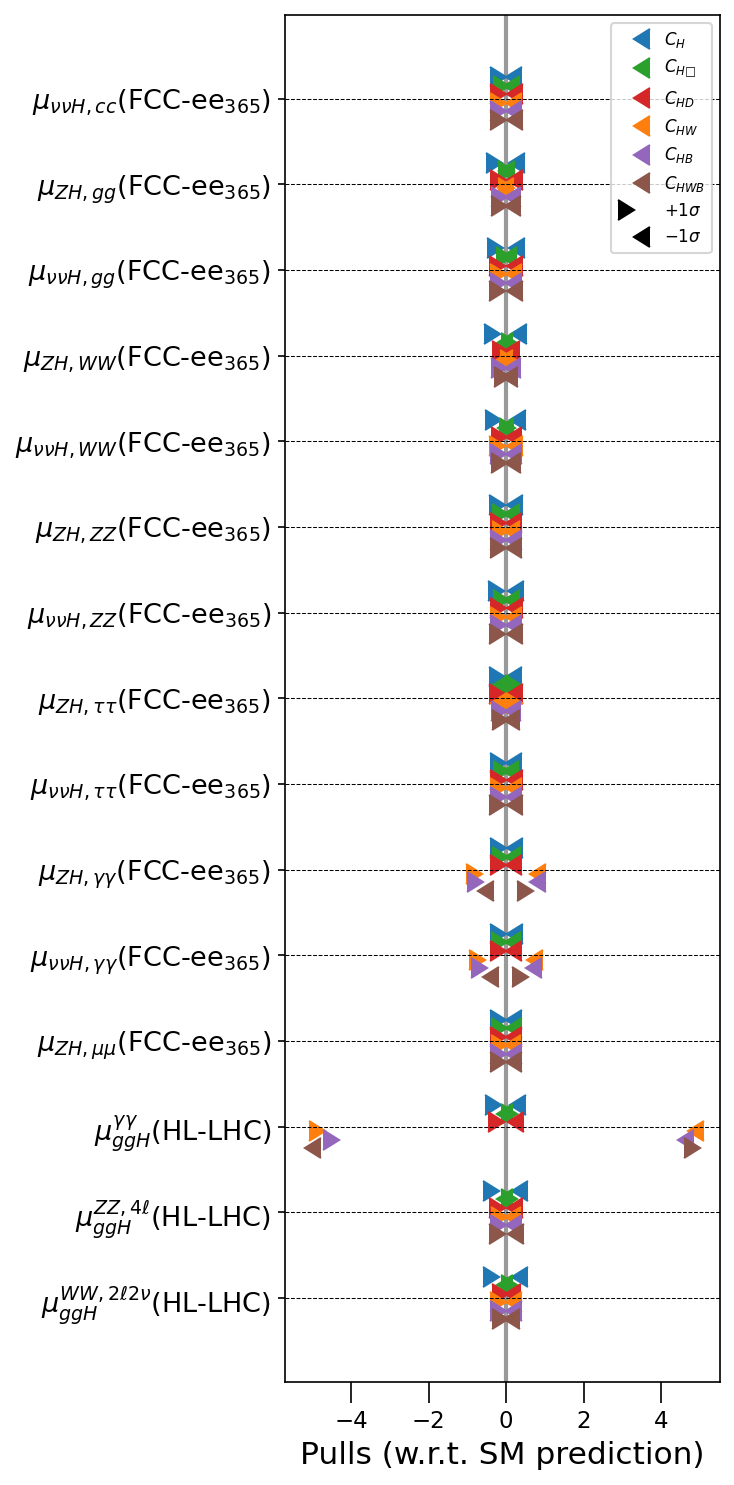

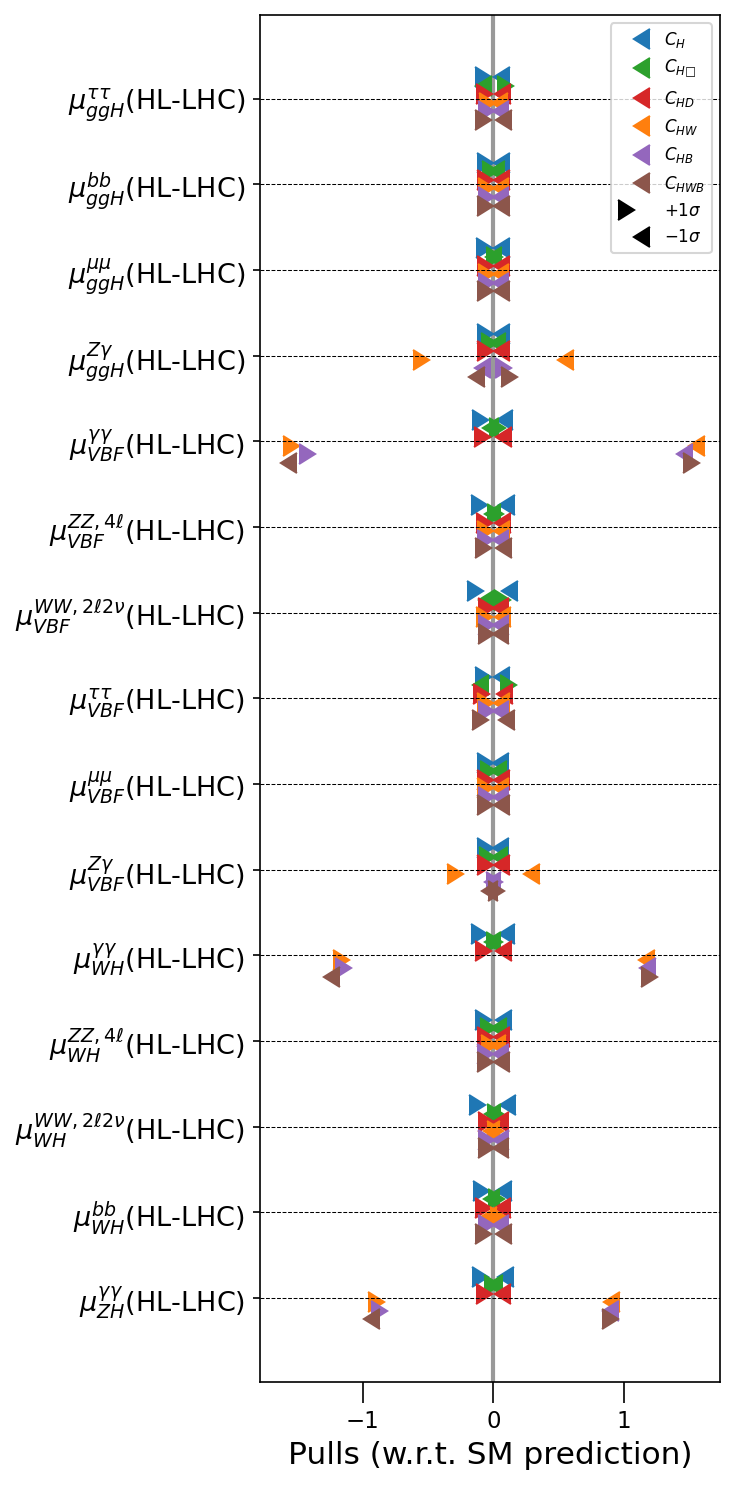

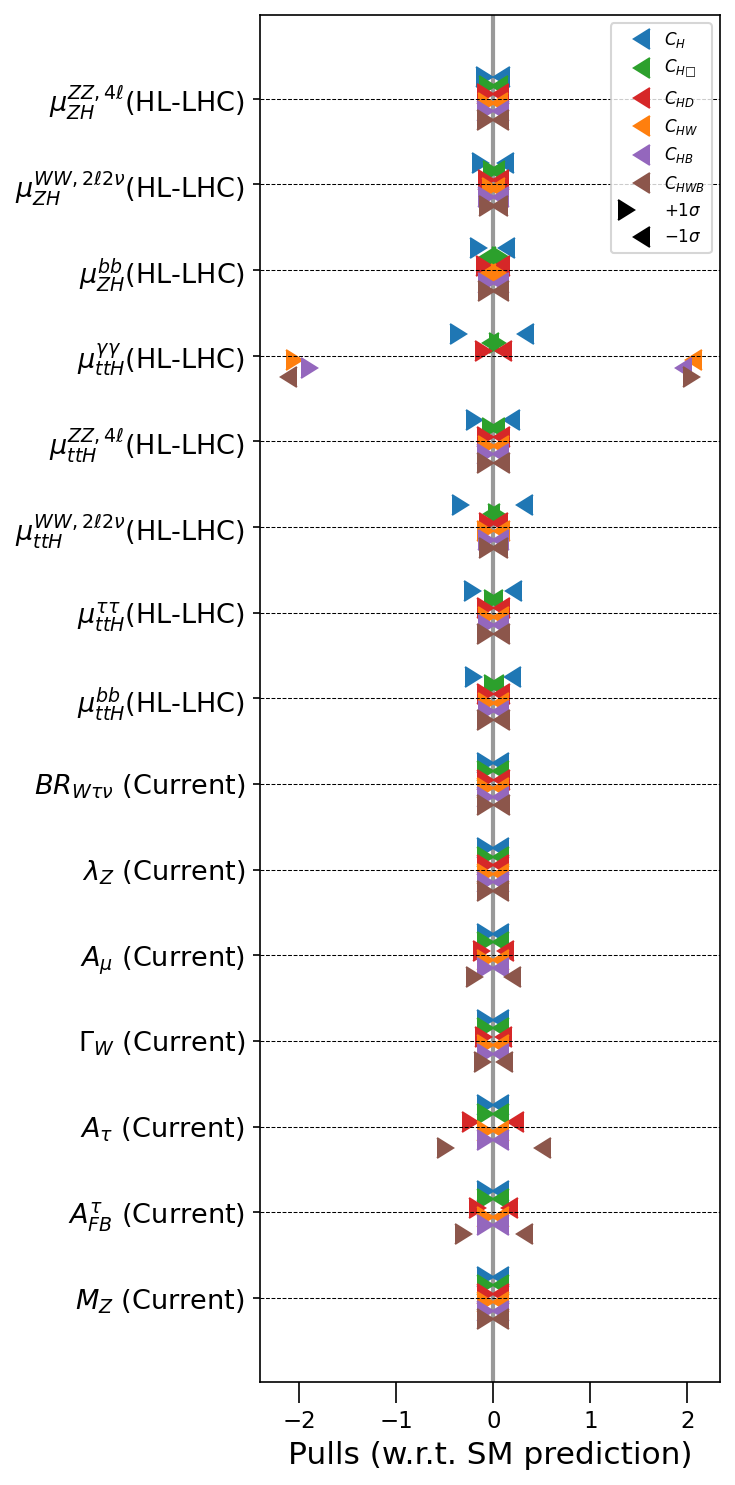

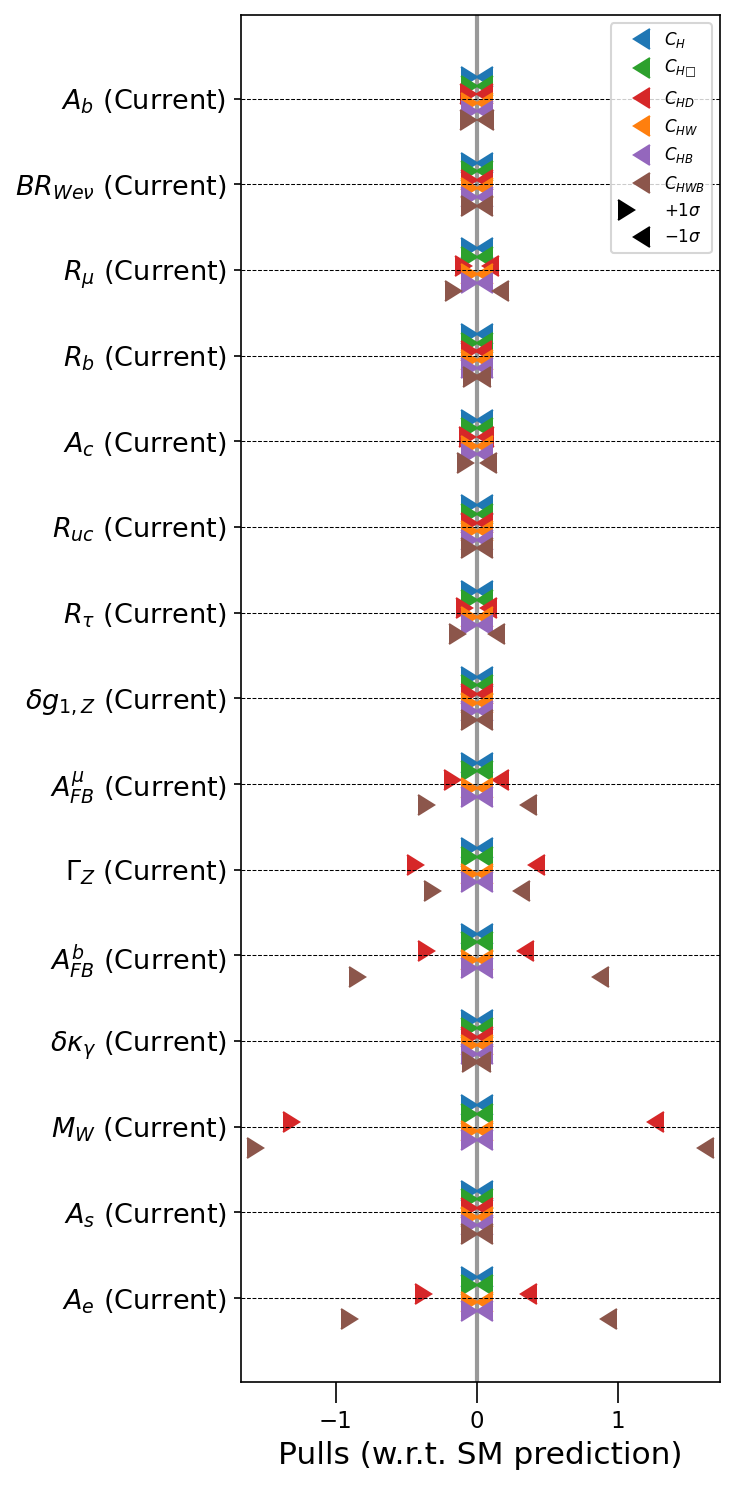

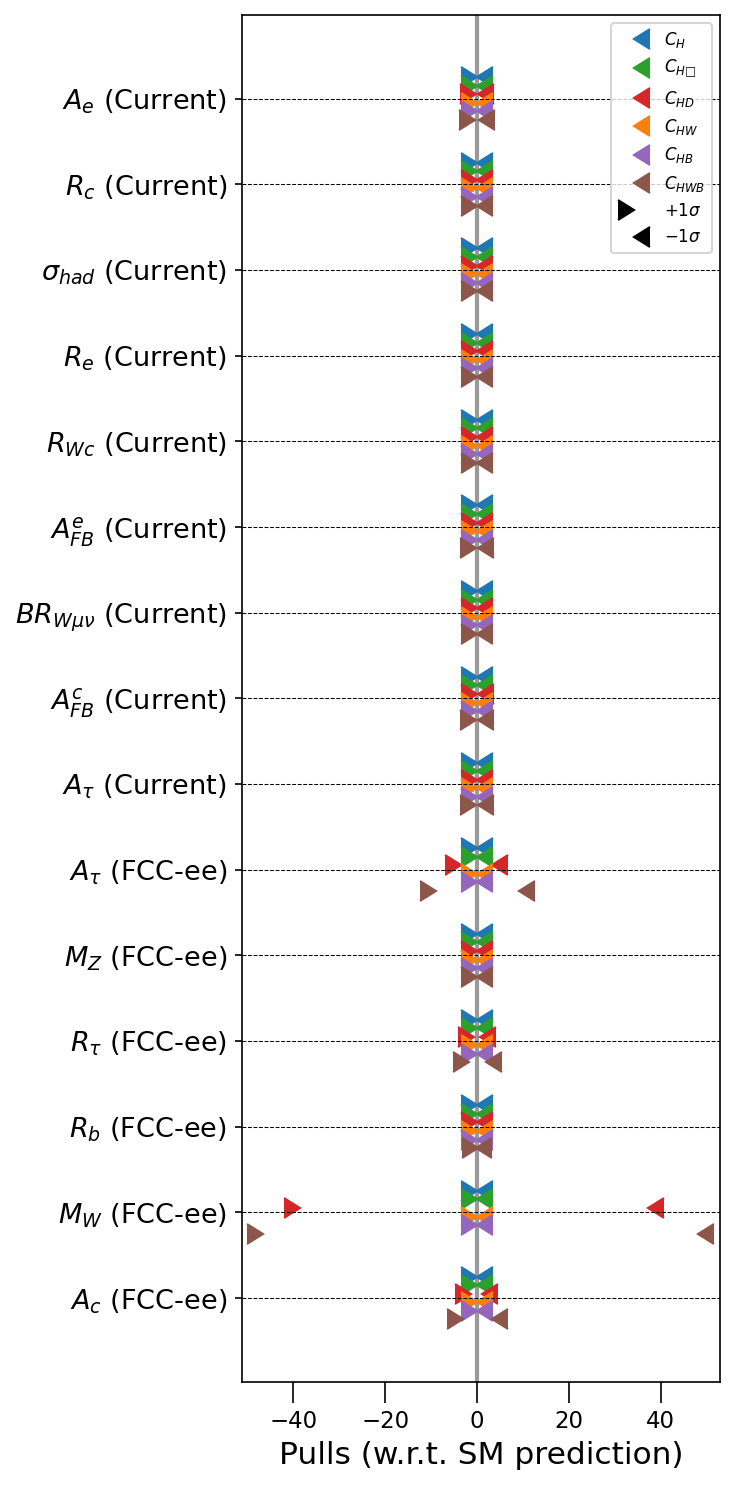

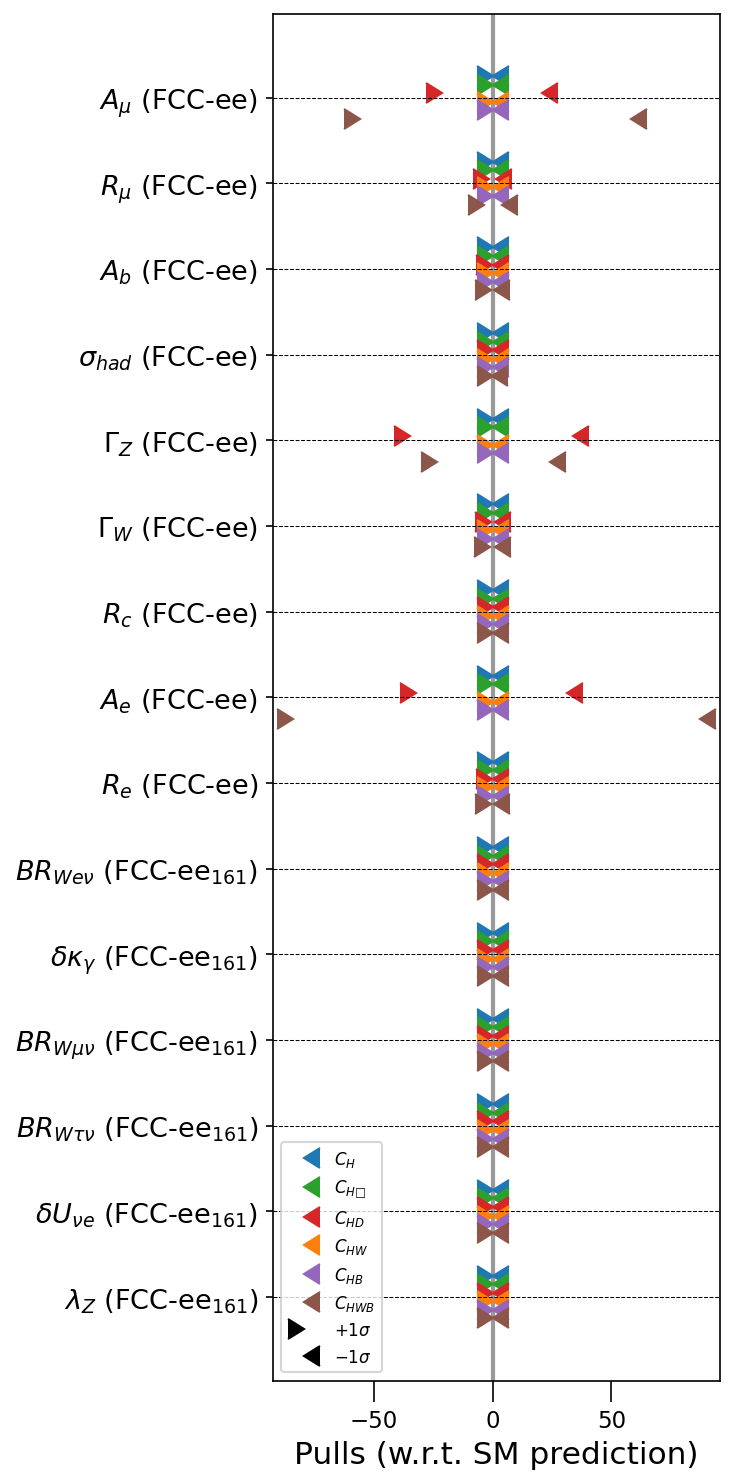

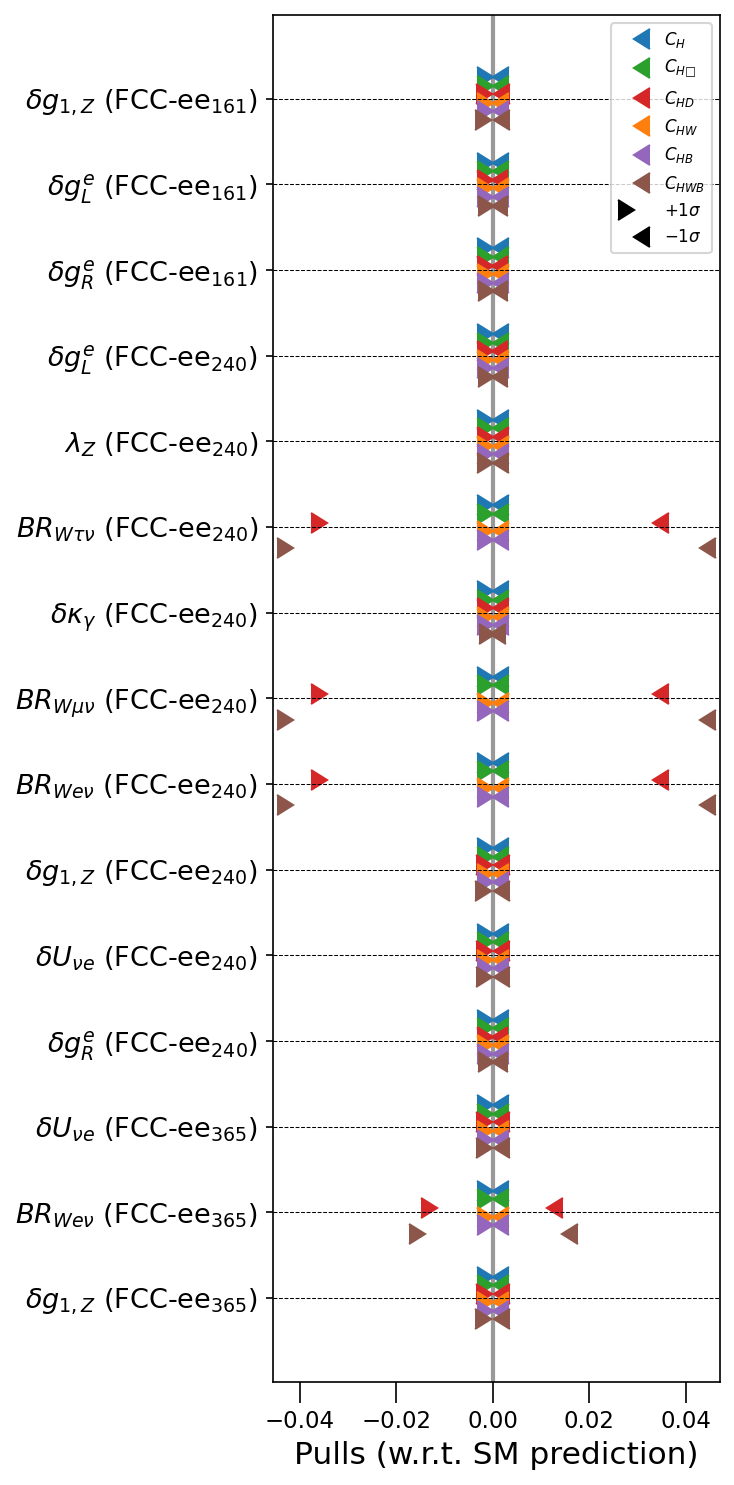

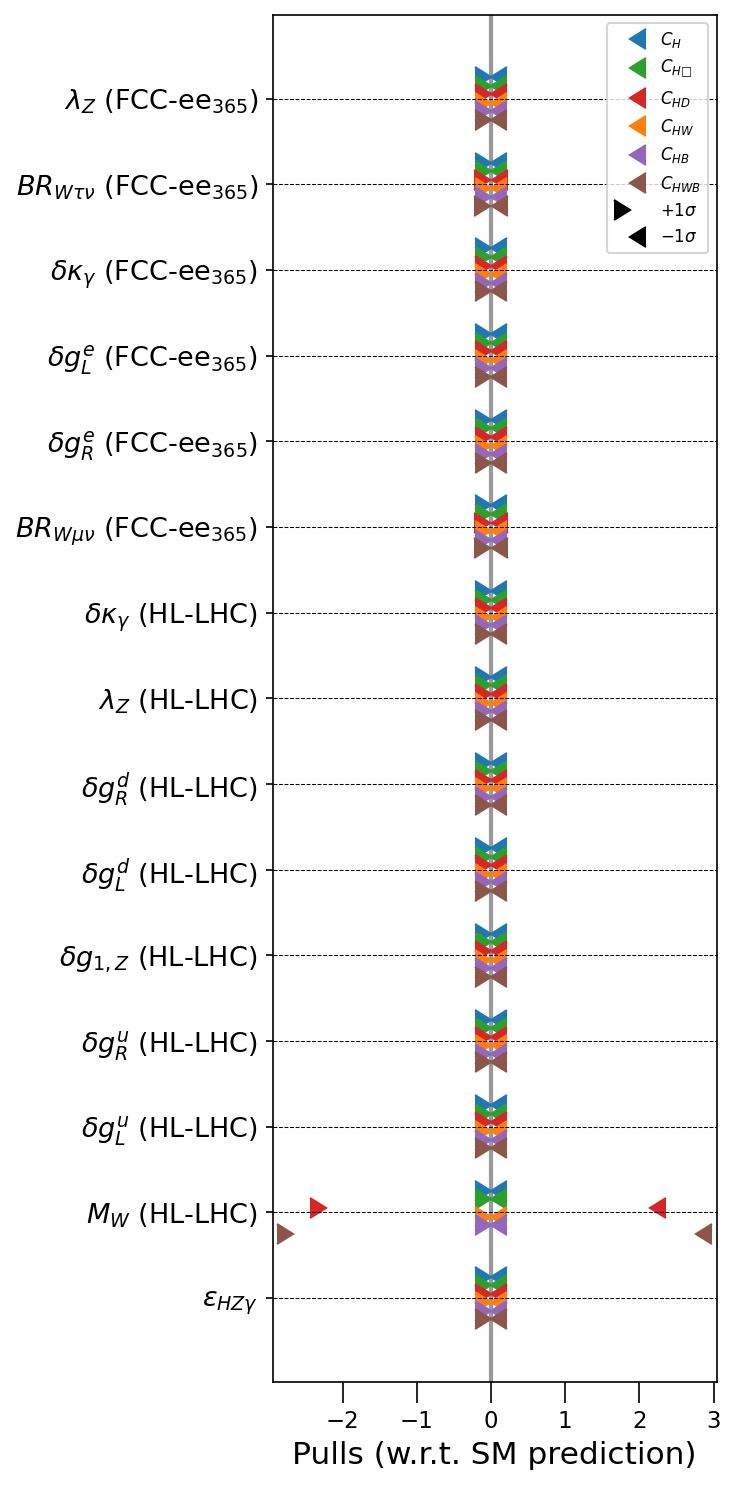

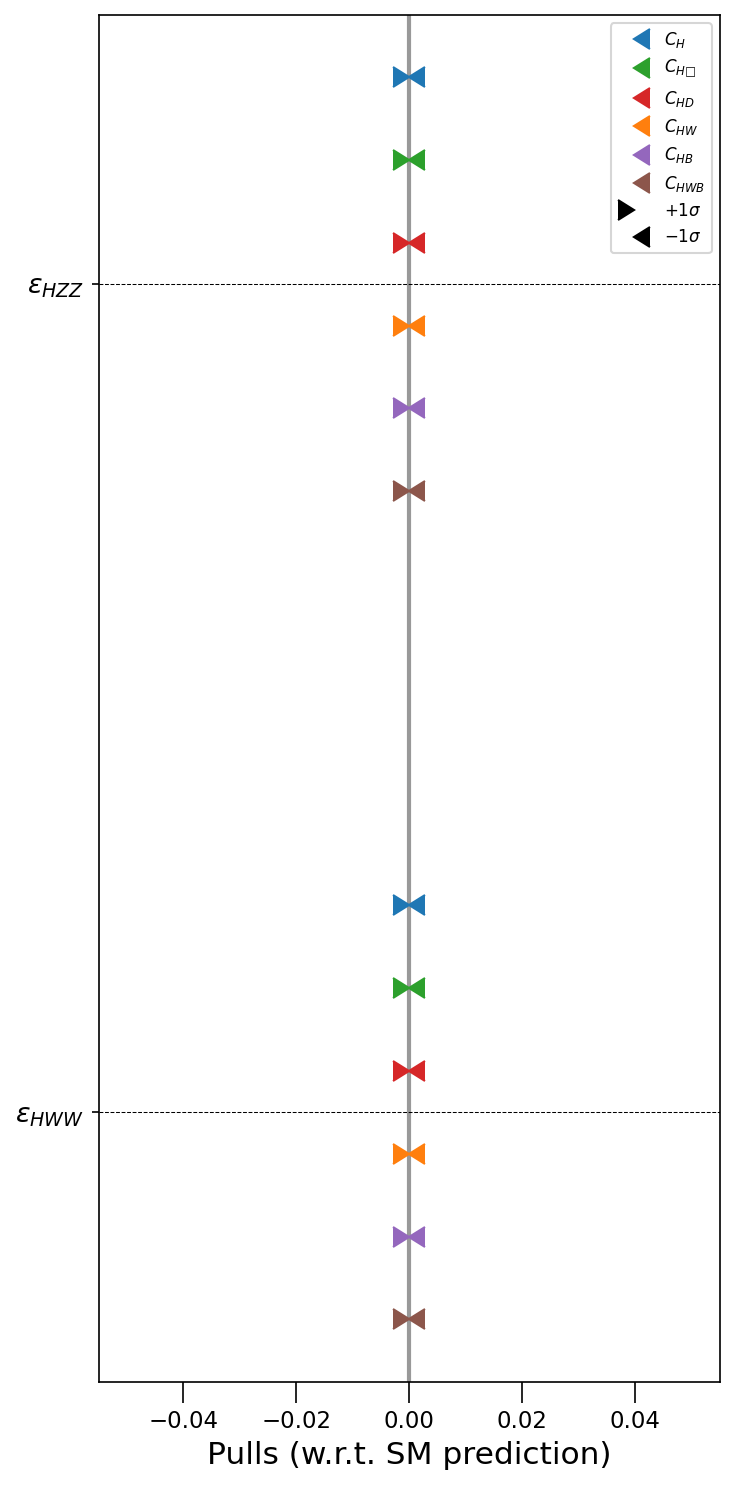

In [36]:
WCs = ["CH", "CHbox", "CHD", "CHW", "CHB", "CHWB"]
file_suffix = "_select"

pullplots.generate_pull_plots_obs(
    BPs,
    model_specs,
    working_dir,
    results_dir,
    model_specs_labels=None,
    plot_titles=plot_titles,
    model="SM",
    only_obs=None,
    skip_obs=None,
    colors=colors,
    show_plots=True,
    nvar_per_plot=nvar_per_plot,
    only_higgs_fccee_obs=False,
    compare_with_SM=False,
    WC_list_for_prediction_pulls=WCs,
    figsize=figsize,
    legend_loc=legend_loc,
    file_suffix=file_suffix,
    save_fig=True,
)

## Correlations

Reading file: ./SM_fit/./results_fits_small_priors_strict/Observables/Statistics.txt
Found 29 observables in the correlation matrix




Producing plot for scenario ., model specification fits_small_priors_strict, BP SM_fit
Total number of WCs considered for the plot: 9
WCs considered for the plot: ['CH', 'CHbox', 'CHD', 'CHW', 'CHB', 'CHWB', 'CHe_11', 'CHL1_11', 'CHL3_11']


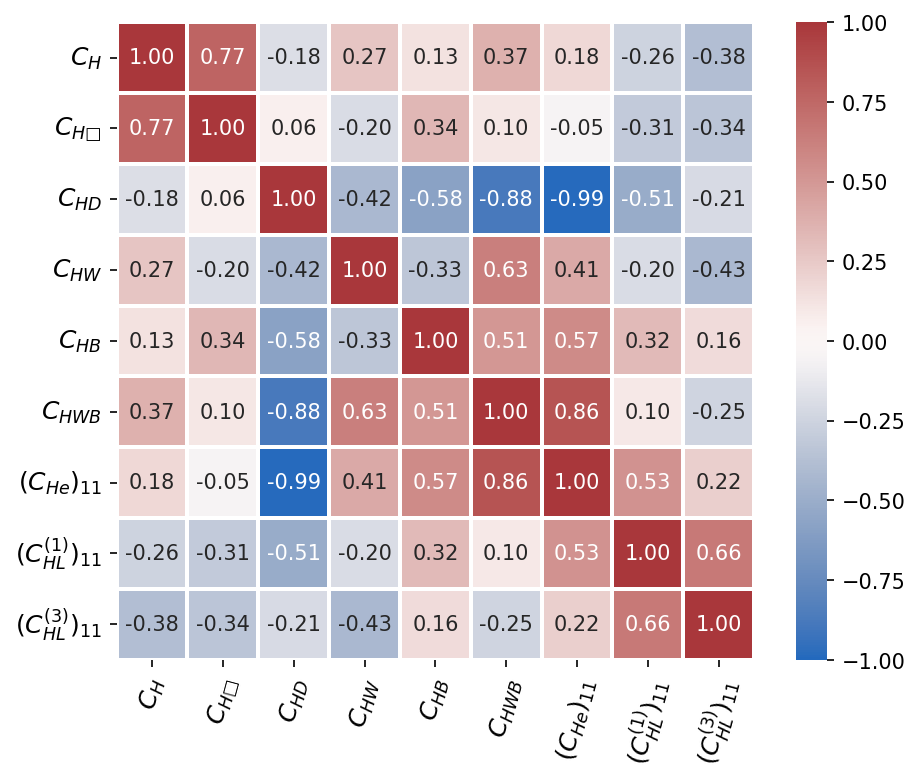

In [37]:
BPs = ["SM_fit", ]
results_dirs = specs
WCs = ["CH", "CHbox", "CHD", "CHW", "CHB", "CHWB", "CHe_11", "CHL1_11", "CHL3_11"]
pullplots.generate_WC_corr_matrix_plot(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dirs,
    WC_names=WCs,
    plot_titles=None,
    show_plots=True,
    figsize=(6.5, 5.3),
    file_suffix="_all",
    save_fig=True,
)

Reading file: ./SM_fit/./results_fits_small_priors_strict/Observables/Statistics.txt
Found 29 observables in the correlation matrix




Producing plot for scenario ., model specification fits_small_priors_strict, BP SM_fit
Total number of WCs considered for the plot: 6
WCs considered for the plot: ['CH', 'CHbox', 'CHD', 'CHW', 'CHB', 'CHWB']


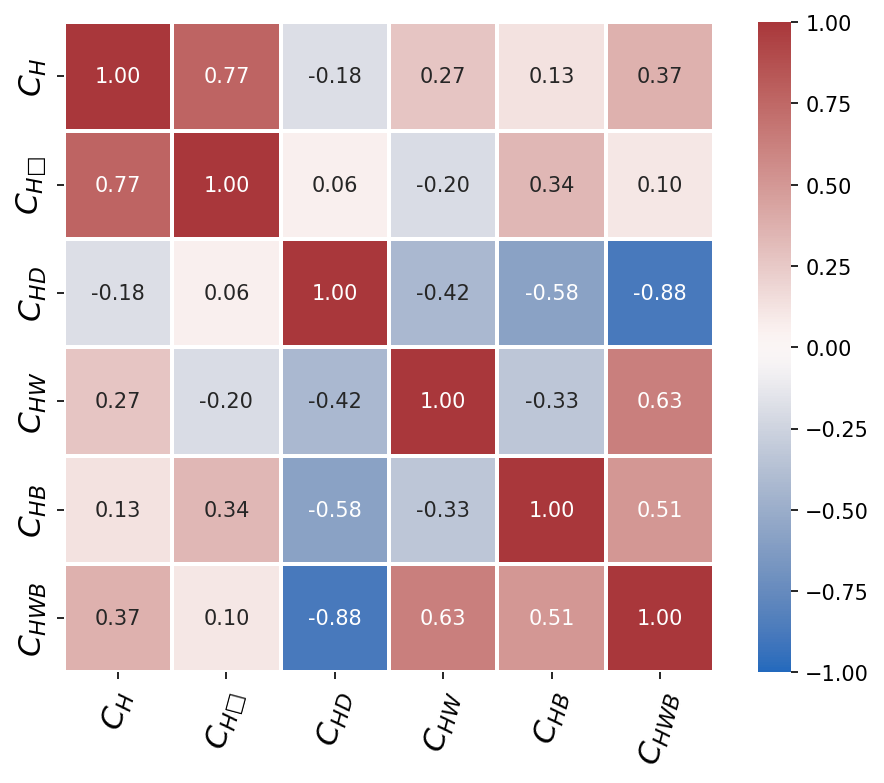

In [38]:
BPs = ["SM_fit", ]
results_dirs = specs
WCs = ["CH", "CHbox", "CHD", "CHW", "CHB", "CHWB",]
pullplots.generate_WC_corr_matrix_plot(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dirs,
    WC_names=WCs,
    plot_titles=None,
    show_plots=True,
    figsize=(6.5, 5.3),
    file_suffix="_select",
    labelsize=15,
    save_fig=True,
)